# 01 — Quickstart: a deterministic soliton, then one photon of vacuum

**Runtime:** about 3 minutes on a laptop CPU (first cell pays a one-off JAX compile).

This notebook walks the shortest useful path through the benchmark:

1. **Install check** — confirm the toolchain and that 64-bit JAX is live.
2. **A deterministic single soliton** — every noise channel off. This is the trajectory
   the golden files pin to 0 ULP.
3. **Turn on quantum vacuum, and nothing else** — watch the spectral floor rise to the
   symmetric-ordered vacuum level $n_\tau^2\,\hbar\omega_0/2$.
4. **Apply `normal_ordered_spectrum()`** — watch it come back down, because that is what
   an optical spectrum analyser would actually read.

Step 4 is the point of the whole notebook. The solver integrates the LLE in the
truncated-Wigner limit, where Wigner moments are *symmetrically* ordered and a vacuum mode
carries $\langle a a^\dagger + a^\dagger a\rangle/2 = 1/2$ of a photon. A photodiode
measures $\langle a^\dagger a\rangle$ and reads **zero** for the vacuum. Comparing a raw
simulated spectrum against a measured one silently adds that half-photon pedestal to the
simulation alone.

Reference throughout: Herr, Tikan & Kippenberg, **arXiv:2604.05897v1** (7 Apr 2026),
Sec. V.B.2, Eq. 126.

## 1. Install check

In [1]:
import pathlib, platform, sys, warnings

# Work whether or not the package is installed: notebooks run with cwd=notebooks/.
try:
    import simulator  # noqa: F401
except ModuleNotFoundError:                       # not pip-installed -- fall back to the checkout
    sys.path.insert(0, str(pathlib.Path.cwd().parent))
    import simulator  # noqa: F401
REPO_ROOT = pathlib.Path(simulator.__file__).resolve().parents[1]

import jax, jaxlib, numpy as np, scipy, matplotlib
import matplotlib.pyplot as plt

# simulator.lle_solver forces jax_enable_x64 at import time. It must be imported
# before any jax.numpy array is created, because JAX bakes the x64 flag in at
# array-creation time.
from simulator.lle_solver import _load_config, hbar_omega0_from_config

print(f"python     {platform.python_version()}")
print(f"jax        {jax.__version__}   jaxlib {jaxlib.__version__}")
print(f"numpy      {np.__version__}   scipy {scipy.__version__}   matplotlib {matplotlib.__version__}")
print(f"devices    {jax.devices()}")
print(f"x64 enabled{'':4}{jax.config.read('jax_enable_x64')}   <- must be True")
assert jax.config.read("jax_enable_x64"), "64-bit JAX is required; import simulator.lle_solver first"

python     3.11.15
jax        0.10.2   jaxlib 0.10.2
numpy      2.4.6   scipy 1.17.1   matplotlib 3.11.1
devices    [CpuDevice(id=0)]
x64 enabled    True   <- must be True


## 2. A deterministic single soliton

`load_cavity_params()` reads `config/sin_params.yaml`; `attach_dispersion()` replaces the
Taylor $\beta$ polynomial with the **measured** $D_\mathrm{int}(\mu)$ grid.

`access_by_seeding` warm-starts an analytic sech ansatz at the target detuning and
integrates to steady state. The sign convention is
$\delta\omega = \omega_\mathrm{res} - \omega_\mathrm{pump}$, so **positive is red-detuned,
the soliton side**; $8\kappa$ sits inside the seeded existence window at $P_\mathrm{in}$ =
214 mW.

`PRODUCTION_NUMERICS` is the quantitative-spectrum stack: 4 Strang sub-steps, 2/3
de-aliasing, edge absorber. Every noise channel is **off by default** — `NoiseConfig`'s
switch fields all default to `False` — so this cell is fully deterministic.

In [2]:
from analysis.dks_access import (PRODUCTION_NUMERICS, access_by_seeding,
                                 attach_dispersion, load_cavity_params)
from simulator.noise_config import NoiseConfig

warnings.simplefilter("ignore")          # the sech ansatz overflows cosh in its far tails

N_TAU, T_SLOW = 2048, 12_000
cav = attach_dispersion(load_cavity_params(), n_tau=N_TAU)

print(f"kappa   = {cav.kappa:.4e} rad/s")
print(f"kappa_c = {cav.kappa_c:.4e} rad/s")
print(f"t_r     = {cav.t_r:.4e} s   ({T_SLOW} round trips = {T_SLOW * cav.t_r * 1e6:.2f} us)")

[dispersion] measured FSR = 2.445164e+10 Hz vs config 2.460000e+10 Hz (rel diff 0.60%); local D2 = 4.9804e+04 rad/s^2 vs config D2 = 3.7699e+04 rad/s^2.
kappa   = 1.5188e+08 rad/s
kappa_c = 1.2150e+08 rad/s
t_r     = 4.0650e-11 s   (12000 round trips = 0.49 us)


In [3]:
deterministic = access_by_seeding(
    8.0 * cav.kappa, cav, t_slow=T_SLOW, n_tau=N_TAU,
    noise_config=NoiseConfig.all_off(thermal_feedback=True),   # every stochastic channel OFF
    **PRODUCTION_NUMERICS,
)
m = deterministic["metrics"]
print(f"single soliton      : {deterministic['is_single']}")
print(f"class label         : {m['np_label']}  (6 = single DKS)")
print(f"temporal peaks      : {m['n_peaks']}")
print(f"sech^2 envelope corr: {m['sech2_env_corr']:.3f}")
print(f"U_int (final)       : {m['u_int_final']:.4e} J*s")

[thermal pre-flight] t_r/tau_th = 8.130e-06, Euler eigenvalue = 0.999991870 (stable if |.|<1), R_th = 5.443e-01 K/W, worst-case (Δω=0) thermal_shift = 7.82×κ, operating-point thermal_shift = 0.03×κ (limit 15.0×κ)


single soliton      : True
class label         : 6  (6 = single DKS)
temporal peaks      : 1
sech^2 envelope corr: 0.932
U_int (final)       : 8.8417e-22 J*s


`thermal_feedback=True` is not a noise channel — it is the deterministic thermo-optic ODE,
and the committed device config runs with it on. `NoiseConfig.all_off()` deliberately
leaves it at its own default rather than forcing it, so it has to be named explicitly.

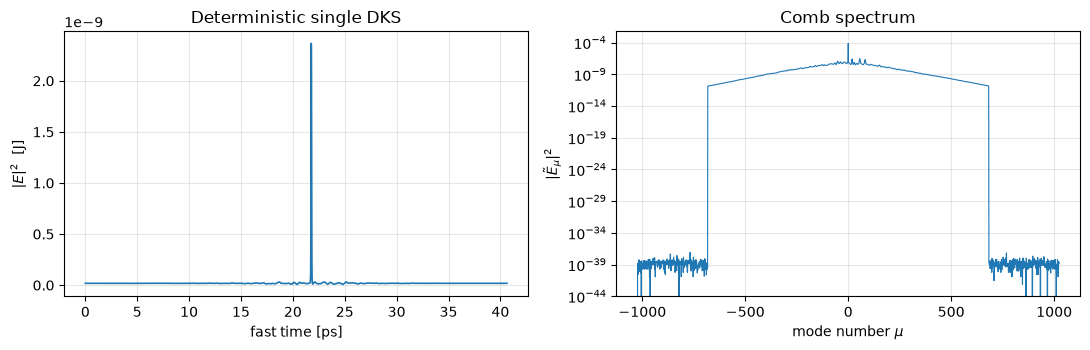

In [4]:
e = deterministic["e_final"]
tau = np.arange(N_TAU) / N_TAU * cav.t_r * 1e12          # ps within one round trip
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].plot(tau, np.abs(e) ** 2, lw=1.2)
ax[0].set(xlabel="fast time [ps]", ylabel=r"$|E|^2$  [J]", title="Deterministic single DKS")
mu = np.fft.fftshift(np.fft.fftfreq(N_TAU) * N_TAU)
ax[1].semilogy(mu, np.abs(np.fft.fftshift(np.fft.fft(e))) ** 2, lw=0.8)
ax[1].set(xlabel=r"mode number $\mu$", ylabel=r"$|\tilde E_\mu|^2$", title="Comb spectrum")
for a in ax:
    a.grid(alpha=0.3)
fig.tight_layout()

## 3. Quantum vacuum only — the floor rises to $\hbar\omega_0/2$ per mode

Two things change for this section.

**A bigger grid.** The vacuum pedestal is a *per-mode* level, so to see it we need a band
of modes that the soliton comb has already decayed out of. `wing_band()` is the
repository's own measurement band, $|\mu| \in [0.244\,n_\tau,\ 0.317\,n_\tau]$, chosen to
sit inside the 2/3 de-aliasing window — beyond $n_\tau/3$ the modes are zeroed after every
nonlinear kick and would read artificially low. At $n_\tau = 4096$ that band is far enough
out that the deterministic comb tail is already ~200x below the pedestal.

**Settle once, record twice.** Both runs start from the *same* settled field, so the only
difference between them is the Langevin drive.

In [5]:
from analysis.dks_access import PIN_W, _run, sech_soliton_seed
from analysis.quantum_noise_report import wing_band

N_TAU_Q = 4096
cav_q = attach_dispersion(load_cavity_params(), n_tau=N_TAU_Q)
dw = 8.0 * cav_q.kappa

hbar_omega0 = hbar_omega0_from_config(_load_config())
pedestal = N_TAU_Q ** 2 * hbar_omega0 / 2.0        # symmetric-ordered vacuum, raw |FFT|^2 units
lo, hi = wing_band(N_TAU_Q)

print(f"hbar*omega0            = {hbar_omega0:.4e} J")
print(f"pedestal n_tau^2*hw0/2 = {pedestal:.4e}")
print(f"wing band              = |mu| in [{lo}, {hi}]   (2/3 boundary at {N_TAU_Q // 3})")

[dispersion] measured FSR = 2.445164e+10 Hz vs config 2.460000e+10 Hz (rel diff 0.60%); local D2 = 4.9804e+04 rad/s^2 vs config D2 = 3.7699e+04 rad/s^2.
hbar*omega0            = 1.2816e-19 J
pedestal n_tau^2*hw0/2 = 1.0751e-12
wing band              = |mu| in [999, 1298]   (2/3 boundary at 1365)


In [6]:
seed_field = sech_soliton_seed(dw, cav_q, n_tau=N_TAU_Q, pin=PIN_W)
settled = _run(dw, 4_000, cav_q, e0=seed_field, seed=0, n_tau=N_TAU_Q, pin=PIN_W,
               snapshot_interval=4_000, **PRODUCTION_NUMERICS)
e_settled = np.asarray(settled["e_final"])[0]
dt_settled = float(np.asarray(settled["delta_t_final"]).ravel()[0])
print(f"settled: DeltaT = {dt_settled:.4e} K")

[thermal pre-flight] t_r/tau_th = 8.130e-06, Euler eigenvalue = 0.999991870 (stable if |.|<1), R_th = 5.443e-01 K/W, worst-case (Δω=0) thermal_shift = 7.82×κ, operating-point thermal_shift = 0.03×κ (limit 15.0×κ)


settled: DeltaT = 1.1542e-05 K


In [7]:
records = {}
for tag, qn in (("vacuum OFF", False), ("vacuum ON", True)):
    r = _run(dw, 2_000, cav_q, e0=e_settled, delta_t0=dt_settled, seed=1,
             n_tau=N_TAU_Q, pin=PIN_W, snapshot_interval=2_000,
             quantum_noise_enabled=qn, **PRODUCTION_NUMERICS)
    records[tag] = np.asarray(r["e_final"])[0]
print("done:", list(records))

[thermal pre-flight] t_r/tau_th = 8.130e-06, Euler eigenvalue = 0.999991870 (stable if |.|<1), R_th = 5.443e-01 K/W, worst-case (Δω=0) thermal_shift = 7.82×κ, operating-point thermal_shift = 0.03×κ (limit 15.0×κ)


[thermal pre-flight] t_r/tau_th = 8.130e-06, Euler eigenvalue = 0.999991870 (stable if |.|<1), R_th = 5.443e-01 K/W, worst-case (Δω=0) thermal_shift = 7.82×κ, operating-point thermal_shift = 0.03×κ (limit 15.0×κ)
[quantum noise] hbar*omega0 = 1.2816e-19 J, U_vac = n_tau*hbar*omega0/2 = 2.625e-16 J, Kerr shift gamma*U_vac = 2.701e+02 rad/s = 1.78e-06*kappa (XPM cross-check 2*gamma*U_vac = 5.402e+02 rad/s), per-round-trip per-quadrature injection std = 9.001e-10 (field units), per-event (fine cadence, dt = t_r/1) std = 9.001e-10


done: ['vacuum OFF', 'vacuum ON']


In [8]:
mu_q = np.fft.fftshift(np.fft.fftfreq(N_TAU_Q) * N_TAU_Q)
band = (np.abs(mu_q) >= lo) & (np.abs(mu_q) <= hi)
power = lambda field: np.abs(np.fft.fftshift(np.fft.fft(field))) ** 2

floor = {tag: float(np.mean(power(f)[band])) for tag, f in records.items()}
for tag, v in floor.items():
    print(f"{tag:11s} wing floor = {v:.4e}   = {v / pedestal:9.4f} x pedestal")

vacuum OFF  wing floor = 5.7472e-15   =    0.0053 x pedestal
vacuum ON   wing floor = 1.0956e-12   =    1.0191 x pedestal


With the channel off, the wing carries only the soliton's own comb tail — a few thousandths
of the vacuum level. With it on, the floor lands within a couple of percent of exactly
$n_\tau^2\hbar\omega_0/2$: **half a photon per mode**, which is the symmetric-ordered
vacuum occupation and precisely what Eq. 126 prescribes.

## 4. `normal_ordered_spectrum()` — what the instrument would read

`analysis.spectral_metrics.normal_ordered_spectrum` subtracts the pedestal:

$$S_\mathrm{normal} = |\tilde E_\mu|^2 - n_\tau^2\,\hbar\omega_0/2$$

Pass `clip=False` whenever you intend to average or fit. Subtraction removes the vacuum's
**bias**, not its **variance**: a single-snapshot vacuum mode is exponentially distributed
with mean and standard deviation both equal to the pedestal, so individual residuals are
routinely *negative*. Clipping at zero turns a zero-mean residual into a positively biased
one and destroys exactly the cancellation that averaging relies on.

In [9]:
from analysis.spectral_metrics import normal_ordered_spectrum

raw_on = power(records["vacuum ON"])
normal_on = np.fft.fftshift(
    normal_ordered_spectrum(np.fft.ifftshift(raw_on), N_TAU_Q, hbar_omega0, clip=False)
)

f_raw = float(np.mean(raw_on[band]))
f_norm = float(np.mean(normal_on[band]))
n_modes = int(band.sum())

print(f"raw (symmetric-ordered) wing floor : {f_raw:+.4e}  = {f_raw / pedestal:8.4f} x pedestal")
print(f"normally-ordered wing floor        : {f_norm:+.4e}  = {f_norm / pedestal:8.4f} x pedestal")
print(f"suppression                        : {f_raw / abs(f_norm):.1f}x")
print()
print(f"modes averaged in the band         : {n_modes}")
print(f"expected residual ~ pedestal/sqrt(N): {1 / np.sqrt(n_modes):.4f} x pedestal")

raw (symmetric-ordered) wing floor : +1.0956e-12  =   1.0191 x pedestal
normally-ordered wing floor        : +2.0584e-14  =   0.0191 x pedestal
suppression                        : 53.2x

modes averaged in the band         : 600
expected residual ~ pedestal/sqrt(N): 0.0408 x pedestal


The residual does not go to zero, and it should not. Averaging $N$ independent
exponentially-distributed modes leaves a standard error of pedestal$/\sqrt{N}$ — printed
above next to what we actually measured. A comb feature is resolvable only once it exceeds
that standard error.

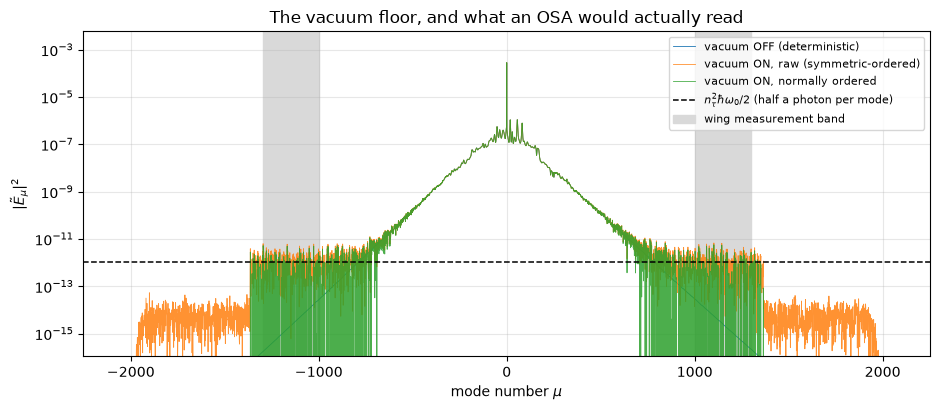

In [10]:
fig, ax = plt.subplots(figsize=(9.5, 4.2))
ax.semilogy(mu_q, np.maximum(power(records["vacuum OFF"]), 1e-30), lw=0.6,
            label="vacuum OFF (deterministic)")
ax.semilogy(mu_q, np.maximum(raw_on, 1e-30), lw=0.6, alpha=0.85,
            label="vacuum ON, raw (symmetric-ordered)")
ax.semilogy(mu_q, np.maximum(normal_on, 1e-30), lw=0.6, alpha=0.85,
            label="vacuum ON, normally ordered")
ax.axhline(pedestal, color="k", ls="--", lw=1.1,
           label=r"$n_\tau^2\hbar\omega_0/2$ (half a photon per mode)")
ax.axvspan(lo, hi, color="0.85", zorder=0)
ax.axvspan(-hi, -lo, color="0.85", zorder=0, label="wing measurement band")
ax.set(xlabel=r"mode number $\mu$", ylabel=r"$|\tilde E_\mu|^2$",
       title="The vacuum floor, and what an OSA would actually read",
       ylim=(pedestal * 1e-4, None))
ax.legend(fontsize=8, loc="upper right")
ax.grid(alpha=0.3)
fig.tight_layout()

## What to read next

* **`docs/QUICKSTART.md`** — the same ground at a slower pace, plus cold-start access.
* **`docs/NOISE_MODELS.md`** — the physics of all eight channels.
* **`docs/LIMITATIONS.md`** — read this before quoting any number, especially the
  truncated-Wigner validity condition ($\langle n\rangle \gg 1$) and the
  symmetric-ordering caveat this notebook just demonstrated.
* **`notebooks/02_noise_budget.ipynb`** — from a `NoiseConfig` to a budget cell with
  error bars.